# Hand-Written Number Classifier

### written by: [Jehwan Kim](github.com/kreimben)

In [4]:
import base64
import json
import random
from io import BytesIO
import copy

import lightning as L
import matplotlib.pyplot as plt
from PIL import Image
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.tuner import Tuner
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms.functional import to_pil_image
import torch

from src.module import ResNet, ResidualBlock

%matplotlib inline

In [2]:
download_dir = './data'

train_data = datasets.MNIST(
    root=download_dir,
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

valid_data = datasets.MNIST(
    root=download_dir,
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

test_data = datasets.MNIST(
    root=download_dir,
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

In [3]:
len(train_data), len(valid_data), len(test_data)

(60000, 10000, 10000)

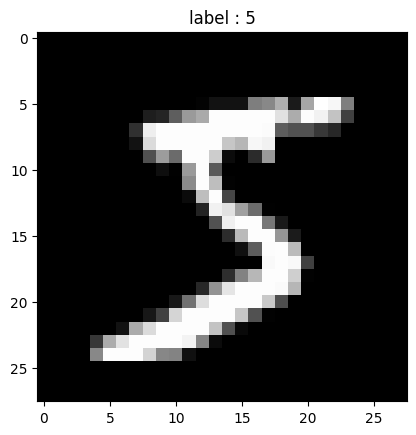

In [4]:
# Sometimes, plot doesn't work cuz I included normaliser and auto augment function.
image, label = train_data[0]
plt.imshow(image.squeeze().numpy(), cmap='gray')
plt.title(f'label : {label}')
plt.show()

In [5]:
# I already ready for dataloader in the lightning module.
# So delete the class.
del train_data, valid_data, test_data, image, label

### Training with LearningRateFinder.

In [6]:
checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',  # Monitor validation loss for improvement
    dirpath='./',  # Directory where the checkpoints will be saved
    filename='resnet-{epoch:02d}-{val_loss:.2f}',  # Checkpoint file name pattern
    save_top_k=3,  # Save the top 3 models according to the monitored metric
    mode='min',  # The 'min' mode means the checkpoint with the lowest val_loss will be saved
)

In [7]:
trainer = L.Trainer(max_epochs=20, callbacks=[
    EarlyStopping(monitor="val_acc", min_delta=0.0001),
    checkpoint_callback,
], accelerator='cpu')
tuner = Tuner(trainer)
model = ResNet(block=ResidualBlock, layers=[3, 4, 6, 3], grayscale=True)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/kreimben/Repository/MNISTClassifier/venv/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/kreimben/Repository/MNISTClassifier/venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


/Users/kreimben/Repository/MNISTClassifier/venv/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:652: Checkpoint directory /Users/kreimben/Repository/MNISTClassifier exists and is not empty.
/Users/kreimben/Repository/MNISTClassifier/venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:436: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.
/Users/kreimben/Repository/MNISTClassifier/venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:436: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Learning rate set to 0.0009120108393559097
Restoring states from the checkpoint path at /Users/kreimben/Repository/MNISTClassifier/.lr_find_d0e3a580-1b2e-421c-855b-885fa4df1107.ckpt
Restored all states from the checkpoint at /Users/kreimben/Repository/MNISTClassifier/.lr_find_d0e3a580-1b2e-421c-855b-885fa4df1107.ckpt


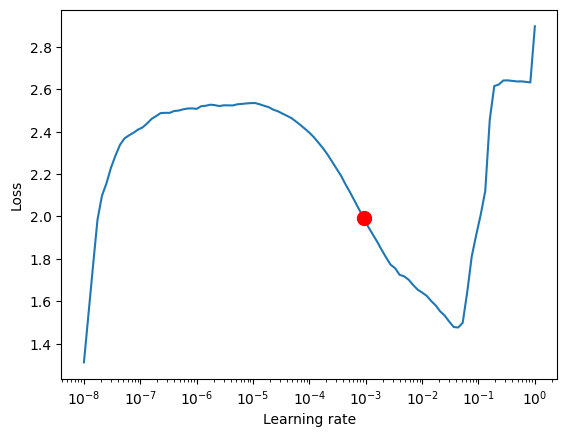

In [8]:
lr_finder = tuner.lr_find(model)

lr_finder.plot(suggest=True)

new_lr = lr_finder.suggestion()

model.hparams.learning_rate = new_lr

In [9]:
trainer.fit(model)


   | Name     | Type               | Params
-------------------------------------------------
0  | loss     | CrossEntropyLoss   | 0     
1  | accuracy | MulticlassAccuracy | 0     
2  | conv1    | Conv2d             | 3.1 K 
3  | bn1      | BatchNorm2d        | 128   
4  | relu     | ReLU               | 0     
5  | maxpool  | MaxPool2d          | 0     
6  | layer1   | Sequential         | 221 K 
7  | layer2   | Sequential         | 1.1 M 
8  | layer3   | Sequential         | 6.8 M 
9  | layer4   | Sequential         | 13.1 M
10 | avgpool  | AdaptiveAvgPool2d  | 0     
11 | fc       | Linear             | 5.1 K 
-------------------------------------------------
21.3 M    Trainable params
0         Non-trainable params
21.3 M    Total params
85.134    Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [10]:
trainer.test(model)

/Users/kreimben/Repository/MNISTClassifier/venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:436: Consider setting `persistent_workers=True` in 'test_dataloader' to speed up the dataloader worker initialization.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9786999821662903
        test_loss           0.07040748000144958
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.07040748000144958, 'test_acc': 0.9786999821662903}]

### Save the model

In [ ]:
# trainer.save_checkpoint('mnist.ckpt')
# torch.save(model.state_dict(), 'state_dict.ckpt')

### Predict through json file. (encoded image)

In [2]:
# del model

import torch
from src.module import ResNet, ResidualBlock

model = ResNet.load_from_checkpoint('mnist.ckpt')#, block=ResidualBlock, layers=[3, 4, 6, 3], grayscale=True)
model.eval()

ResNet(
  (loss): CrossEntropyLoss()
  (accuracy): MulticlassAccuracy()
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affi

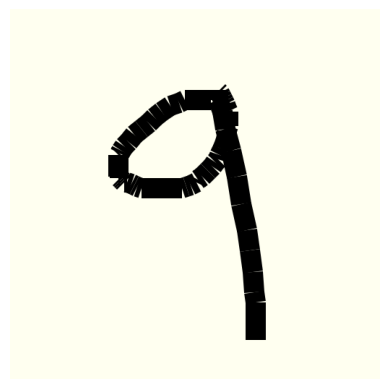

In [5]:
with open("test_data.json", 'r') as f:
    body = json.loads(f.read())

image_data = body['image']
image_decoded = base64.b64decode(image_data)
image = Image.open(BytesIO(image_decoded))#.convert('L')

# Invert the image
# image = Image.eval(image, lambda x: 255 - x)

plt.imshow(image)
plt.axis('off')  # Optional: Hide the axis
plt.show()

In [6]:
from app import transform

# Preprocess the image
image_tensor = transform(image).unsqueeze(0)  # Add batch dimension
# image_tensor = image_tensor.unsqueeze(0)
m = image_tensor.numpy()

TypeError: 'tuple' object is not callable

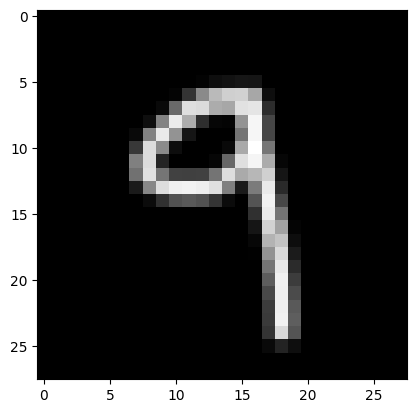

In [7]:
# check tensored image.
import matplotlib.pyplot as plt


def show_image(image_tensor):
    image_tensor = copy.deepcopy(image_tensor)

    # Assuming `image_tensor` is your transformed image tensor
    image_tensor = image_tensor.squeeze(0)  # Remove batch dimension if present

    # Denormalize
    image_tensor = image_tensor * 0.5 + 0.5  # Assuming normalization mean=0.5, std=0.5

    # Convert to numpy array
    image_numpy = image_tensor.numpy()

    # If it's a grayscale image (1, H, W), convert to (H, W) for displaying
    if image_numpy.shape[0] == 1:
        image_numpy = image_numpy.squeeze(0)

    # Display the image
    plt.imshow(image_numpy, cmap='gray' if image_numpy.ndim == 2 else None)
    print(image_numpy.shape())
    plt.axis('off')  # Hide axes ticks
    plt.show()


show_image(image_tensor)

In [8]:
# Predict
with torch.no_grad():
    prediction = model(image_tensor)

# Process the prediction as needed
# For example, convert tensor to JSON serializable output
prediction_result = prediction.argmax().item()
prediction_result

9

### test by mnist data.

In [9]:
# encode the image like above process.
with open('test_image.png', 'rb') as image_file:
    encoded_string = base64.b64encode(image_file.read()).decode('utf-8')

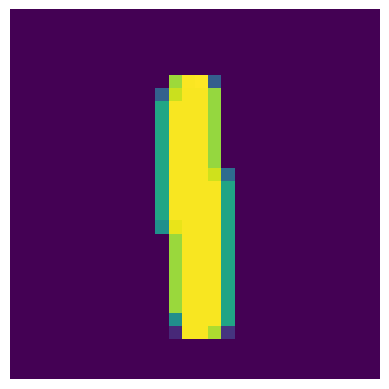

In [10]:
image_decoded = base64.b64decode(encoded_string)
image = Image.open(BytesIO(image_decoded))

plt.imshow(image)
plt.axis('off')  # Optional: Hide the axis
plt.show()

In [11]:
from app import transform

# Preprocess the image
image_tensor = transform(image).unsqueeze(0)  # Add batch dimension
# image_tensor = image_tensor.unsqueeze(0)
m = image_tensor.numpy()

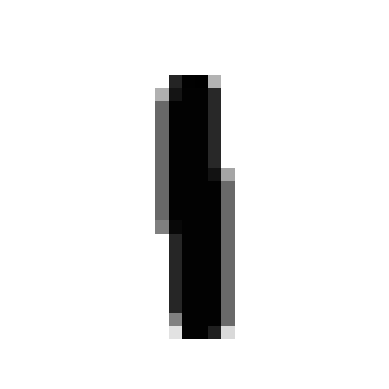

In [12]:
# check tensored image.
import matplotlib.pyplot as plt
import copy


def show_image(image_tensor):
    image_tensor = copy.deepcopy(image_tensor)

    # Assuming `image_tensor` is your transformed image tensor
    image_tensor = image_tensor.squeeze(0)  # Remove batch dimension if present

    # Denormalize
    image_tensor = image_tensor * 0.5 + 0.5  # Assuming normalization mean=0.5, std=0.5

    # Convert to numpy array
    image_numpy = image_tensor.numpy()

    # If it's a grayscale image (1, H, W), convert to (H, W) for displaying
    if image_numpy.shape[0] == 1:
        image_numpy = image_numpy.squeeze(0)

    # Display the image
    plt.imshow(image_numpy, cmap='gray' if image_numpy.ndim == 2 else None)
    plt.axis('off')  # Hide axes ticks
    plt.show()


show_image(image_tensor)

In [13]:
import torch

# Predict
with torch.no_grad():
    prediction = model(image_tensor)

# Process the prediction as needed
# For example, convert tensor to JSON serializable output
prediction_result = prediction.argmax().item()
prediction_result

1

### mnist data (directly)

In [34]:
dataset = datasets.MNIST(root='data', train=True, transform=transforms.ToTensor(), download=True)
image, label = dataset[random.randint(0, len(dataset) - 1)]
image = to_pil_image(image)

8

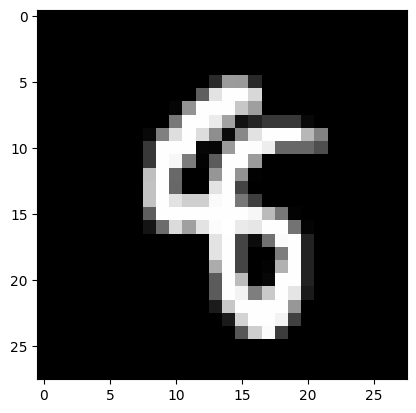

In [35]:
plt.imshow(image, cmap='gray')
label

In [36]:
from app import transform

# Preprocess the image
image_tensor = transform(image).unsqueeze(0)  # Add batch dimension
m = image_tensor.numpy()

In [37]:
import torch

# Predict
with torch.no_grad():
    prediction = model(image_tensor)

# Process the prediction as needed
# For example, convert tensor to JSON serializable output
prediction_result = prediction.argmax().item()
assert prediction_result == label

AssertionError: 